# Keras

Wir verwenden die folgenden Plattformen, um unsere AI Exploration weiterzuführen:

* **Keras**: eine AI-Plattform, die auf das **TensorFlow**-Backend von Google aufsetzt.

Wir möchten das gleiche Problem lösen wie im restlichen Kurs: die Erkennung der MNIST-Digits.

Zuerst importieren wir die nötigen Bibliotheken:

In [ ]:
%pip install --upgrade numpy tensorflow matplotlib keras scikit-learn

# Imports
import numpy as np
from tensorflow import keras
from keras import layers
from matplotlib import pyplot
from sklearn.metrics import confusion_matrix
import itertools


## Das MNIST-Dataset
Das MNIST-Dataset ist bereits als Beispiel verfügbar.

In [59]:
mnist_digits = keras.datasets.mnist.load_data()

Wir bereiten das Modell vor und teilen das Dataset in vier Teile:
* Train vs. Test
  * Train: verwenden wir, um eine AI zu trainieren
  * Test: verwenden wir, um die Qualität der AI zu messen (die Test-Daten dürfen nicht fürs Training verwendet werden, sonst könnte die AI die Daten auswendig lernen (overfitting)).
* `x` vs. `y`
  * `x` bezeichnet üblicherweise die Quelldaten, im Beispiel die Bilder (Pixel).
  * `y` bezeichnet üblicherweise die Labels (also die wahren Werte, den _ground truth_).

In [60]:
# Split the data between train and test sets
(x_train, y_train), (x_test, y_test) = mnist_digits

Wir schauen uns an, wie die Daten aussehen:

Shape of training data (x_train): (60000, 28, 28)
Content of labels (y_train[0]): 5


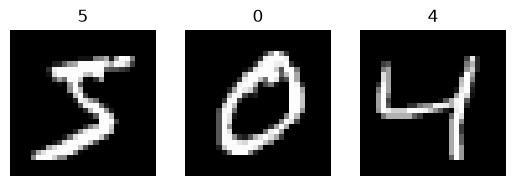

In [61]:
print(f"Shape of training data (x_train): {x_train.shape}")
print(f"Content of labels (y_train[0]): {y_train[0]}")

fig, axs = pyplot.subplots(ncols=3)
# Lets print a few samples:
for i in range(3):
    # Plot raw pixel data aus x_train
    axs[i].imshow(x_train[i], cmap='gray')
    axs[i].set_title(y_train[i])
    axs[i].set_axis_off()

Was sagt uns das?
  * Wir haben 60'000 Bilder.
  * Ein einzelnes Training-Bild hat die Shape (Format) von 28x28 Pixeln.
  * Jedes Pixel ist eine Zahl im Bereich [0,255], die wir als Graustufenwert interpretieren.
  * Labels sind einzelne Werte, die die richtige Zahl enthalten.

Die Daten müssen noch etwas massiert werden, um die richtige Form ("shape") zu haben:
  * Skalierung: Statt Integer-Werte von 0-255 verwenden wir floats im Bereich [0, 1].
  * Labels: Statt eines Integer-Labels von 0-9 verwenden wir das gleiche Format wie die zehn Output-Neuronen, also einen Vektor mit Länge 10, wobei alle ausser dem richtigen Element null sind, das richtige 1.

In [62]:
# Model / data parameters
num_classes = 10  # Number of unique digits
input_shape = (28, 28)  # 28x28 pixels

# Scale [0, 255] pixels to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

# Convert class vectors to binary class matrices (one-hot encoding)
print(f"Labels before one-hot categorical conversion: shape: {y_train.shape}, example: {y_train[0]}")
labels_test = y_test 
labels_train = y_train 
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(f"Labels after one-hot categorical conversion: shape: {y_train.shape}, example: {y_train[0]}")

60000 train samples
10000 test samples
Labels before one-hot categorical conversion: shape: (60000,), example: 5
Labels after one-hot categorical conversion: shape: (60000, 10), example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Build the Model

Nun können wir das neuronale Netzwerk definieren. Wir wählen ein simples Netzwerk: 
* ein Input-Layer, der _flachgedrückt_ (flattened) wird, d.h. aus 28x28 Pixel werden 784x1 Zahlen.
  * dieser Layer ändert nur das Layout der Daten, aber enthält keine lernenden Neuronen.
* einen hidden Layer mit 30 Neuronen. `Dense` bedeutet, dass der Layer _fully-connected_ ist, also dass jedes der 784 Input-Neuronen durch eine Synapse mit jedem Hidden-Neuron verbunden ist.
* ein Output-Layer, der auf die zehn möglichen Ziffern (_categories_) schliesst.
* als [Activation-Function](https://ml-cheatsheet.readthedocs.io/en/latest/nn_concepts.html#activation-functions) wählen wir [softmax](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#softmax)
  * softmax berechnet einen Vektor mit der Betragssumme 1 und kann so als Wahrscheinlichkeitsverteilung über die 10 Klassen angesehen werden.

In [41]:
model = keras.Sequential(
    [
       keras.Input(shape=input_shape),
       layers.Flatten(),
       layers.Dense(30, activation="sigmoid"),
       layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_18 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

Die Anzahl Parameter pro Layer ergibt sich aus der Anzahl Synapsen (Verbindungen: 784 * 30) plus der Anzahl _Biases_ (je einer pro Neuron, also 1 * 30).

## Train the Model

Wir können das Modell bereits trainieren. Das Training teilt sich zweifach:
* _Batch_: Anzahl Samples (Trainings-Daten) die mit dem gleichen Modell evaluiert werden, bevor das Modell geändert wird.
  * Die Gradienten werden addiert.
  * Nach dem Batch wird das Modell anhand der akkumulierten Gradienten angepasst.
  * Je nach Optimizer werden alle (Batch Gradient Descent) oder nur ein paar wenige (Stochastic Gradient Descent) Samples des Batch für die Back Propagation verwendet.
  * Das Vorgehen im Batch verhindert, dass einzelne extreme Datenpunkte das Modell in eine ungünstige Richtung zerren.
* _Epoche_: Wie oft das ganze Dataset trainiert wird.
  * Ist `epochs=1` hat jedes Sample genau eine Chance, das Modell zu beinflussen.
  * Nach jeder Epoche wird validiert, wie gut das Modell bereits ist. Dazu wird ein Teil der Trainings-Daten evaluiert. `validation_split=0.1` besagt, dass 10% der Trainingsdaten für die Validierung zur Seite gestellt werden.
  * Bei einer `batch_size = 128` und `validation_split=0.1` gibt es `60000*(1-0.1)/128 = 422` Model Updates pro Epoche.

Man kann sich das als zwei verschachtelte for-Loops vorstellen: Der äussere Loop definiert die Epochen und teilt das Dataset in Batches auf. Der innere Loop evaluiert jeden Batch und akkumuliert dabei den Fehler. Am Schluss jedes Batches wird das Modell angepasst mit Back Prop.

Wir müssen angeben
* Loss-Funktion - wir wählen `categorical_crossentropy` ([Details hier](https://ml-cheatsheet.readthedocs.io/en/latest/loss_functions.html#cross-entropy)).
* Optimizer - es gibt mittlerweile eine Vielzahl von Backprop-Algorithmen, die schneller konvergieren als SGD (_Stochastic Gradient Descent_), wir verwenden den populären [Adam](https://en.wikipedia.org/wiki/Stochastic_gradient_descent#Adam)-Algorithmus.

In [42]:
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - accuracy: 0.7989 - loss: 1.0111 - val_accuracy: 0.9062 - val_loss: 0.4740
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - accuracy: 0.8970 - loss: 0.4297 - val_accuracy: 0.9242 - val_loss: 0.3090
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.9128 - loss: 0.3276 - val_accuracy: 0.9343 - val_loss: 0.2557
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step - accuracy: 0.9229 - loss: 0.2814 - val_accuracy: 0.9393 - val_loss: 0.2251
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.9296 - loss: 0.2522 - val_accuracy: 0.9420 - val_loss: 0.2067


## Evaluation
Wenn die Train-Accuracy gut genug ist, evaluieren wir das Modell anhand der zu Beginn zurückgestellten Test-Daten.

Die _Accuracy_ misst den Quotienten der richtigen Antworten, 0.92 entspricht also einer Fehlerquote von 8%.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 231us/step - accuracy: 0.9324 - loss: 0.2379
Test loss: 0.23785720765590668
Test accuracy: 0.9323999881744385
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step


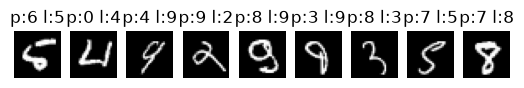

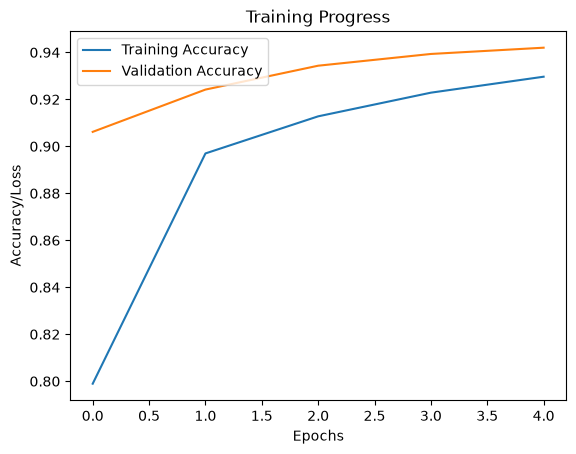

In [76]:
score = model.evaluate(x_test, y_test, verbose=1)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

# Look at false predictions
def show_error_exemplars(model, data, labels):
    predictions = model.predict(data[:1000], batch_size=128)
    max_predictions = np.argmax(predictions, axis=-1)
    max_labels = np.argmax(labels[:1000], axis=-1)

    delta = np.where(np.not_equal(max_predictions, max_labels))[0][:9]
    fig, axs = pyplot.subplots(ncols=9)
    for i, idx in enumerate(delta):
        # Plot raw pixel data aus x_train
        axs[i].imshow(x_test[idx], cmap=pyplot.get_cmap('gray'))
        axs[i].set_title(f"p:{max_predictions[idx]} l:{max_labels[idx]}")
        axs[i].set_axis_off()

def plot_hist(hist):
    pyplot.figure()
    pyplot.plot(hist.history["accuracy"])
    pyplot.plot(hist.history["val_accuracy"])
    # pyplot.plot(hist.history["loss"])
    # pyplot.plot(hist.history["val_loss"])
    pyplot.title("Training Progress")
    pyplot.ylabel("Accuracy/Loss")
    pyplot.xlabel("Epochs")
    pyplot.legend(["Training Accuracy", "Validation Accuracy", "Training Loss", "Validation Loss"], loc="upper left")
    pyplot.show()


show_error_exemplars(model, x_test, y_test)
plot_hist(history)

model.save("mnist_keras_2026.keras")


### Confusion Matrix

Welche Ziffern werden gut erkannt, welche weniger? Die _Confusion-Matrix_ gibt darüber Auskunft:

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 167us/step


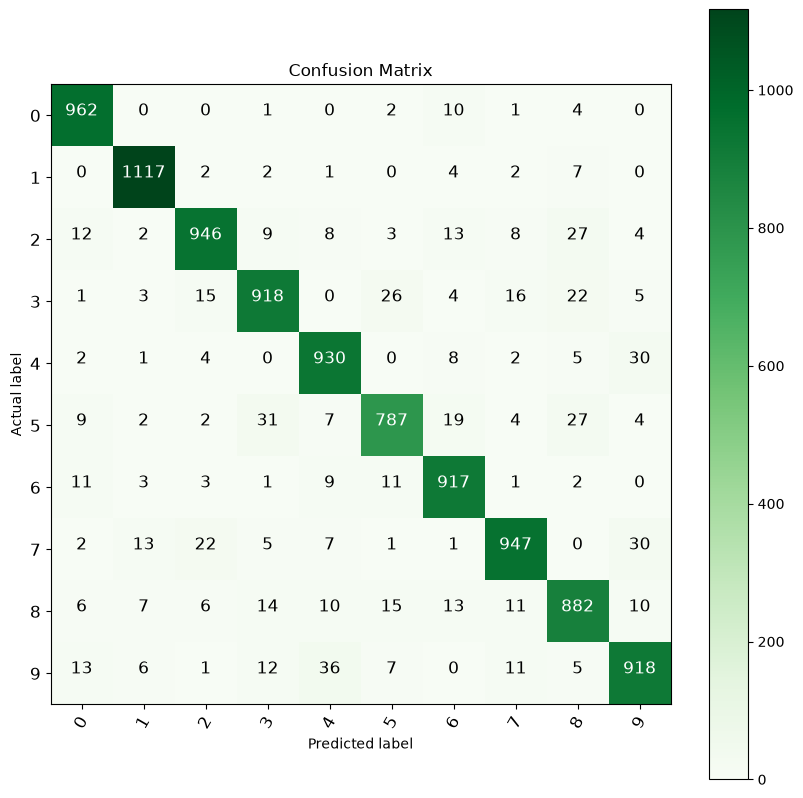

In [73]:
# Stolen from https://github.com/spoluan/mnist-digits-recognition/blob/master/digit-mnist.ipynb

def conf_matrix(y_test=None, y_pred=None, class_names=None):
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = pyplot.subplots(figsize=(10, 10))
    a = ax.matshow(cm, cmap=pyplot.cm.Greens)  
    
    fig.colorbar(a)  
    
    ax.set(title="Confusion Matrix",
             xlabel="Predicted label",
             ylabel="Actual label",
             xticks=np.arange(len(class_names)), 
             yticks=np.arange(len(class_names)), 
             xticklabels=class_names,  
             yticklabels=class_names)
    
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    
    pyplot.xticks(rotation=60, fontsize=12)
    pyplot.yticks(fontsize=12)

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        pyplot.text(j, i, f"{cm[i, j]}",
                  horizontalalignment="center", color="black" if cm[i, j] < (cm.max() + cm.min()) / 2 else "white",
                  fontsize=12)


conf_matrix(y_test=labels_test, y_pred=model.predict(x_test).argmax(axis=1), class_names=list(set(labels_test)))

### Fragen
1. Wie werden die verfügbaren Daten aufgeteilt?
    * in welche Teile mit welcher Funktion?
    * wozu?
2. Was ist das One-Hot-Encoding?
3. Was ist der Unterschied von Batch und Epoche?
4. Was misst die Accuracy eigentlich?

### Aufgaben
1. Spiele mit den _Metaparametern_: was passiert mit der Trainingszeit und der Accuracy wenn du `batch_size` auf `1` setzt? Weshalb?
2. Probiere andere _Optimizer_ aus, zum Beispiel `"SGD"`.
3. Weshalb ist die Accuracy in der Evaluation oft schlechter als während des Trainings rapportiert?

### Moar Layers

Das bestehende Modell ist ja relative einfach - es hat nur einen hidden Layer.
* Können wir besser werden, wenn wir einen (oder 4) zusätzlichen und grösseren hidden Layer einfügen?
* Was passiert mit der Modellgrösse (Anzahl lernbarer Parameter)? Der Trainingszeit?

In [27]:
model2 = keras.Sequential(
    [
       keras.Input(shape=input_shape),
       layers.Flatten(),
       layers.Dense(512, activation="elu"),
       layers.Dense(512, activation="elu"),
       layers.Dense(512, activation="elu"),
       layers.Dense(512, activation="elu"),
       layers.Dense(num_classes, activation="softmax"),
    ]
)

model2.summary()

model2.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history2 = model2.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9110 - loss: 0.2921 - val_accuracy: 0.9572 - val_loss: 0.1396
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9559 - loss: 0.1458 - val_accuracy: 0.9688 - val_loss: 0.1139
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9649 - loss: 0.1114 - val_accuracy: 0.9677 - val_loss: 0.1225
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9727 - loss: 0.0882 - val_accuracy: 0.9743 - val_loss: 0.0946
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9741 - loss: 0.0816 - val_accuracy: 0.9743 - val_loss: 0.0982


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.9724 - loss: 0.0933
Test loss: 0.09330713748931885
Test accuracy: 0.9724000096321106
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


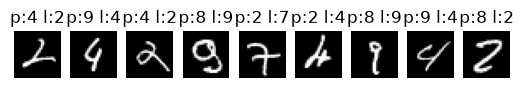

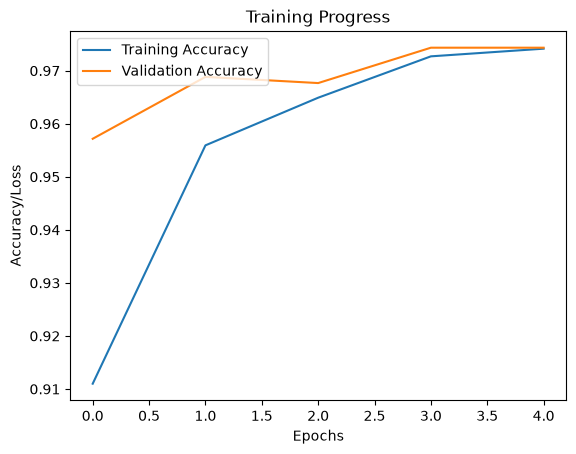

In [28]:
score = model2.evaluate(x_test, y_test, verbose=1)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

show_error_exemplars(model2, x_test, y_test)
plot_hist(history2)

### Kein Overfitting?
Eigentlich wäre zu erwarten, dass ein Netzwerk mit über 1e6 Parametern und 6e4 Samples zu massivem Overfitting neigte: das Modell würde dann die Samples auswendig lernen, aber im Evaluations-Durchgang viel schlechter abschneiden, weil es nicht mehr gut generalisiert.

Interessanterweise scheint das Netzwerk keine Anzeichen für massives Overfitting zu zeigen.

[Hier gibt es ein paar Gedanken](https://datascience.stackexchange.com/questions/19874/why-doesnt-overfitting-devastate-neural-networks-for-mnist-classification) dazu, weshalb das nicht passiert. Oder eher: weshalb man das Overfitting nicht sehen kann.

## Convolutional Neural Networks

Wie können wir unser simples Modell verbessern? Zusätzliche hidden Layers haben nicht den gewünschten Effekt gebracht, aber die Trainingskosten dramatisch vergrössert.

Seit dem Erfolg von [AlexNet (2012)](https://en.wikipedia.org/wiki/AlexNet) ist das Standard-Verfahren dazu die Einführung von convolutional Layers, womit unser Modell ein Convolutional Neural Network (CNN) wird.

Wir beschäftigen uns hier nur ganz kurz mit den grundlegenden Ideen von CNNs - wer mehr dazu wissen möchte, liest bei [Wikipedia](https://en.wikipedia.org/wiki/Convolutional_neural_network) oder im [Deep Learning Book](https://www.deeplearningbook.org/contents/convnets.html).

CNNs werden durch zwei Beobachtungen inspiriert:

### Struktur von Bilddaten

Beim Einsatz eines dense Layers kann jedes Pixel gleichberechtigt mit jedem anderen Pixel die Wahrnehmung beeinflussen. Die Nachbarschaft von zwei Pixel oder die zweidimensionale Struktur des Bildes spielen dabei überhaupt keine Rolle - und tatsächlich haben wir ja oben die Information über die Zweidimensionalität aufgegeben und die Pixels geflatted.

Intuitiv scheint aber klar, dass die Nachbarschaft von Pixeln für die Interpretation des Bildes wichtig ist: Primitive Eigenschaften wie Kanten, aber auch höhere Eigenschaften ("enthält ein Bereich des Bildes ein Auge, eine Nase?") entstehen erst durch die Kombination von mehreren Pixeln auf einem begrenzten Raum. Wir möchten also ein Modell schaffen, das die Nachbarschaft berücksichtigt.

In einer anderen Sichtweise sind die Verbindungen zwischen weit entfernten Pixeln überflüssig, und unser Modell enthält also viel zu viele freie Parameter, die unnötige Trainingszeit und Speicher benötigen.

Eine weitere Beobachtung ist, dass insbesondere primitive Eigenschaften überall im Bild ähnlich aussehen. Beispielsweise können wir eine vertikale Kante detektieren indem wir die Differenz zwischen zwei horizontal benachbarten Pixel berechnen. Diese Differenzberechnung wird aber überall im Bild gleich funktionieren (beispielsweise als Multiplikation mit [-1, 1]). Wir möchten also die gleichen Parameter (Gewichte) für das ganze Bild verwenden (_parameter sharing_).

### Visuelle Verarbeitung im Gehirn
Versuche mit Katzen haben bereits in den 1960er Jahren gezeigt, dass der visuelle Cortex die Bilddaten des Sehnervs räumlich verarbeitet: Die Signale durchlaufen den Cortex in derselben 2D-Struktur, wie sie von der Netzhaut detektiert wurden. Die Schichten des Cortex detektieren mit zunehmender Laufzeit immer höherwertige Eigenschaften des Bildes, also zuerst horizontale und vertikale Kanten, später geometrische Muster, Bildteile wie "Auge", "Nase", und schliesslich werden ganze Konzepte wie "Barack Obama" erkannt. Die ersten Neuronen in den ersten Schichten verarbeiten für die Mustererkennung jeweils nur ein kleines, räumlich begrenztes "receptive Field".

### Umsetzung
Ein Conv-Layer besteht aus einer *Kernel*-Matrix, beispielsweise 3x3 Pixeln. Dieser Kernel wird über alle möglichen Positionen des Inputs geschoben und mit dem aktuellen Ausschnitt multipliziert. Für jeden Ausschnitt wird dabei ein Wert in den Output des Layers geschrieben. 

Haben wir also einen Kernel, der Kanten detektiert, wird der Output ein Bild ähnlich wie dieses Produzieren:

<table>
  <tr>
  <td>
    <figure>
      <img src="https://upload.wikimedia.org/wikipedia/commons/5/50/Vd-Orig.png" alt="Original"/>
    </figure>
  </td>
  <td>
    <figure>
      <img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/1445b36fef5ec4ca0e0b5d7e200c90afaf6af58b" />
    </figure>
  </td>
  <td>
    <figure>
      <img src="https://upload.wikimedia.org/wikipedia/commons/2/20/Vd-Rige1.png" alt="Ridge-Detection"/>
    </figure>
  </td>
  </tr>
  <tr>
  <td>
      <figcaption>Original-Bild</figcaption>
  </td>
  <td>
      <figcaption>Kernel-Matrix</figcaption>
  </td>
  <td>
      <figcaption>Kanten-Features (grau: keine Kante)</figcaption>
  </td>
  </tr>
</table>

[Quelle / Mehr bei Wikipedia](https://en.wikipedia.org/wiki/Kernel_(image_processing))

#### Parameter Sharing
Weil die Kantendetektion überall im Bild gleich läuft, werden die Gewichte für die Kernel-Matrix geteilt. Wir lernen also nicht separate Gewichte für jeden Bildausschnitt, sondern nur 9 Gewichte (für den 3x3-Kernel), was die Komplexität und den Speicherbedarf des Modells massiv reduziert. 

Für den Feed-Forward spielt dies keine grosse Rolle, aber bei der Backpropagation werden die Kernel-Gewichte gemeinsam für alle Bildausschnitte gelernt.

Damit wird Rechenkapazität frei, und wir können stattdessen pro Conv-Layer nicht nur einen, sondern eine Vielzahl (im Beispiel unten: 32) von Kernels trainieren, die unterschiedliche Konzepte in verschiedenen Ausrichtungen detektieren. Oft spricht man bei der Anzahl von Kernels von der Tiefe (_depth_) des Layers.

Je nachdem, wie mit die Ausschnitte am Rand des Bildes behandelt werden, führen Conv-Layers dazu, dass die Output-Grösse etwas kleiner wird als der Input. Bei unserem 3x3-Kernel wird der Output von 28x28 auf 26x26 Pixel gestutzt.

#### Pooling
Für die Bildwahrnehmung ist es oft egal, ob eine Eigenschaft (_Feature_) um ein paar wenige Pixel verschoben auftritt. Dies trifft auf primitive Features (Kanten...) genauso zu wie auf höhere Features ("Auge in der oberen Bildhälfte").

Dazu verwenden wir einen _Max-Pooling-Layer_, d.h. einen Layer ohne trainierbare Parameter der aus einem 2x2-Bereich des Inputs jeweils das Maximum auswählt. Dies führt dazu, dass tiefere Layer nur noch gröbere Informationen über die Positionen der detektierten Features erhalten; entsprechend wird beim Pooling die Output-Grösse halbiert.

<figure>
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/Max_pooling.png" alt="Max-Pooling with a 2x2 window"/>
  <figcaption>Max-Pooling mit 2x2-Fenster</figcaption>
</figure>

#### Zusammenfassung
Das ganze CNN-Modell kann so visualisiert werden (Quelle: WP):

<figure>
  <img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Typical_cnn.png?20151217030420" alt="CNN"/>
  <figcaption>CNN Struktur (Quelle: WP)</figcaption>
</figure>


### Let's Code a CNN

Damit das CNN auf Keras funktioniert, müssen die Daten noch etwas massiert werden: 2-D Convolution Layers erwarten Daten als 3D-Matrix, weil sie von mehreren Farbkanälen ausgehen. Dazu fügen wir eine Dimension hinzu.

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9162 - loss: 0.2891 - val_accuracy: 0.9790 - val_loss: 0.0787
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9759 - loss: 0.0785 - val_accuracy: 0.9825 - val_loss: 0.0680
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9817 - loss: 0.0591 - val_accuracy: 0.9808 - val_loss: 0.0635
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9860 - loss: 0.0478 - val_accuracy: 0.9857 - val_loss: 0.0498
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9877 - loss: 0.0405 - val_accuracy: 0.9878 - val_loss: 0.0432
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - accuracy: 0.9872 - loss: 0.0388
Test loss: 0.03881306201219559
Test accuracy: 0.9872000217437744
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


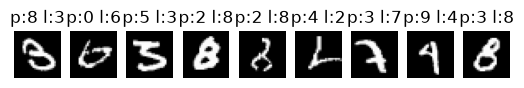

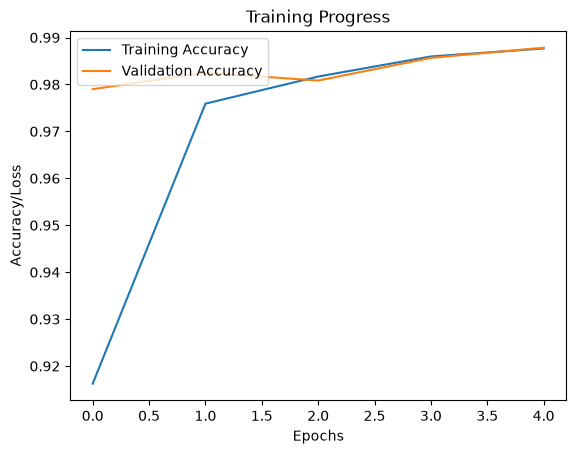

In [44]:
# Make sure images have shape (28, 28, 1)
# -> We append a singleton (depth=1) dimension at the end (-1), so that the dimensionality
#    is the same throughout the model (2D conv layers expect 3 dimensions, because most images
#    have multiple color channels).
input_shape_1 = (28, 28, 1)
x_train_1 = np.expand_dims(x_train, -1)
x_test_1 = np.expand_dims(x_test, -1)
print("x_train shape:", x_train_1.shape)
print(x_train_1.shape[0], "train samples")
print(x_test_1.shape[0], "test samples")

model3 = keras.Sequential(
    [
        # Input layer
        keras.Input(shape=input_shape_1),
        
        # First conv-layer: train 32 different 3x3 kernels.
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        # Max-pooling downsamples by a factor of 2.
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Second conv-layer: train 64 detector kernels.
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        # And pool again, arriving at 64 5x5 feature maps.
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Flatten into a single 5x5x64 = 1600 feature vector.
        layers.Flatten(),

        # Fully-connected (dense) output layer to the 10 digits.
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model3.summary()

model3.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history3 = model3.fit(x_train_1, y_train, batch_size=128, epochs=5, validation_split=0.1)

score = model3.evaluate(x_test_1, y_test, verbose=1)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

show_error_exemplars(model3, x_test_1, y_test)
plot_hist(history3)

model3.save("mnist_cnn_2026.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step


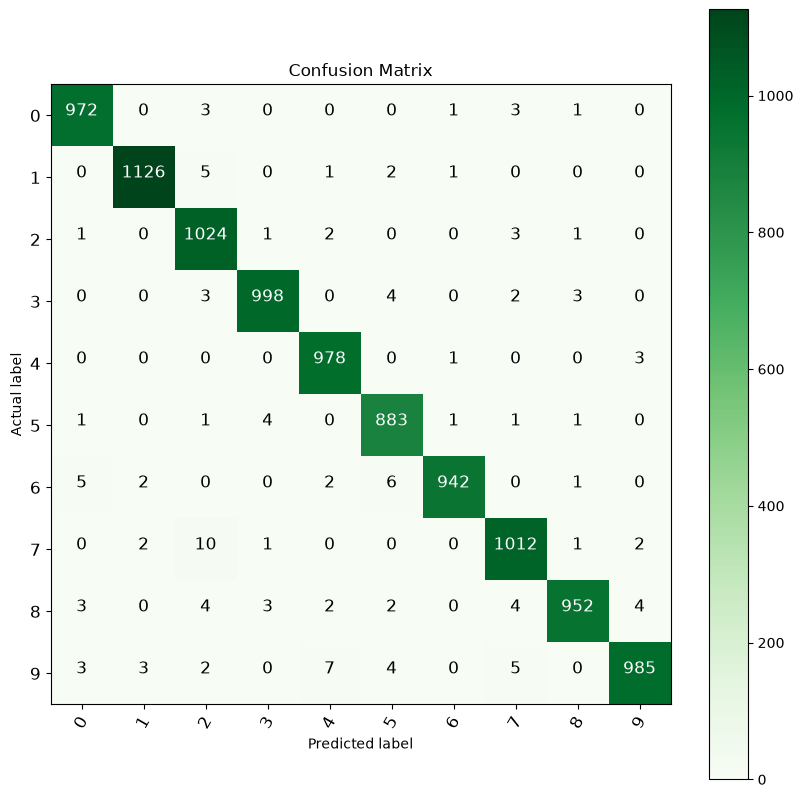

In [75]:
conf_matrix(y_test=labels_test, y_pred=model3.predict(x_test_1).argmax(axis=1), class_names=list(set(labels_test)))

Nicht schlecht: Im Vergleich zu den vielen dense Layers haben wir nur einen Bruchteil der lernbaren Parameter, trotzdem ist die Accuracy nochmals besser geworden!

## Moar Ideas

Wie könnten wir das Modell noch besser machen?

### Data Augmentation

Beim Test zeigt sich, dass das Modell Mühe hat, mit geneigten oder nicht sauber zentrierten Ziffern umzugehen. Wir verbessern die Robustheit, indem wir während des Trainings die Bilder zufällig rotieren, zoomen und verschieben.

### Drop-Out

Grosse Modelle neigen zu _overfitting_: Sie lernen die Trainingsdaten auswendig. Wir erreichen klarere und robustere Entscheidungen, wenn ein Teil der Neuronen während des Trainings zufällig ausgeschaltet werden. Dies geschieht in einem sogenannten _Drop-Out_ Layer.

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_3               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_3            │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7749 - loss: 0.6862 - val_accuracy: 0.9658 - val_loss: 0.1214 - learning_rate: 0.0100
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8856 - loss: 0.3687 - val_accuracy: 0.9658 - val_loss: 0.1349 - learning_rate: 0.0100
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9001 - loss: 0.3251 - val_accuracy: 0.9720 - val_loss: 0.1133 - learning_rate: 0.0100
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9076 - loss: 0.2984 - val_accuracy: 0.9637 - val_loss: 0.1497 - learning_rate: 0.0100
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9111 - loss: 0.2883 - val_accuracy: 0.9700 - val_loss: 0.1112 - learning_rate: 0.0100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.9673 - loss: 0.1218
Test loss: 0.12181109935045242
Test accuracy: 0.9672999978065491
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


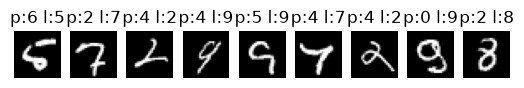

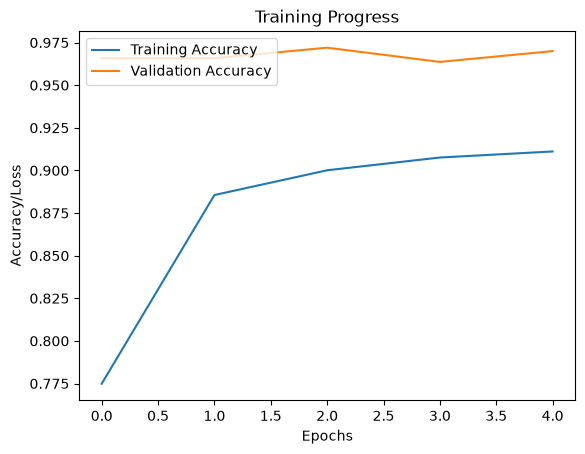

In [45]:
# Make sure images have shape (28, 28, 1)
# -> We append a singleton (depth=1) dimension at the end (-1), so that the dimensionality
#    is the same throughout the model (2D conv layers expect 3 dimensions, because most images
#    have multiple color channels).
input_shape_1 = (28, 28, 1)
x_train_1 = np.expand_dims(x_train, -1)
x_test_1 = np.expand_dims(x_test, -1)
print("x_train shape:", x_train_1.shape)
print(x_train_1.shape[0], "train samples")
print(x_test_1.shape[0], "test samples")

model4 = keras.Sequential(
    [
        # Input layer
        keras.Input(shape=input_shape_1),
        
        # Preprocessing: apply random image transforms to gain more varied training
        # material: Rotate, Zoom, Move (Translate)
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(0.1, 0.1),

        # First conv-layer: train 32 different 3x3 kernels.
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        # Max-pooling downsamples by a factor of 2.
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Second conv-layer: train 64 detector kernels.
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        # And pool again, arriving at 64 5x5 feature maps.
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Flatten into a single 5x5x64 = 1600 feature vector.
        layers.Flatten(),

        # Dropout: Randomly ignore 30% of the neurons in order to fight
        # overfitting
        layers.Dropout(0.3),

        # Fully-connected (dense) output layer to the 10 digits.
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model4.summary()
# Reduce the learning rate over time
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.001)

optimizer = lr_schedule = keras.optimizers.Adam(0.01)
model4.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history4 = model4.fit(x_train_1, y_train, batch_size=128, epochs=5, validation_split=0.1, callbacks=[reduce_lr])

score = model4.evaluate(x_test_1, y_test, verbose=1)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

show_error_exemplars(model4, x_test_1, y_test)
plot_hist(history4)

# Modell abspeichern
model4.save("mnist_cnn_2026_pp.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step


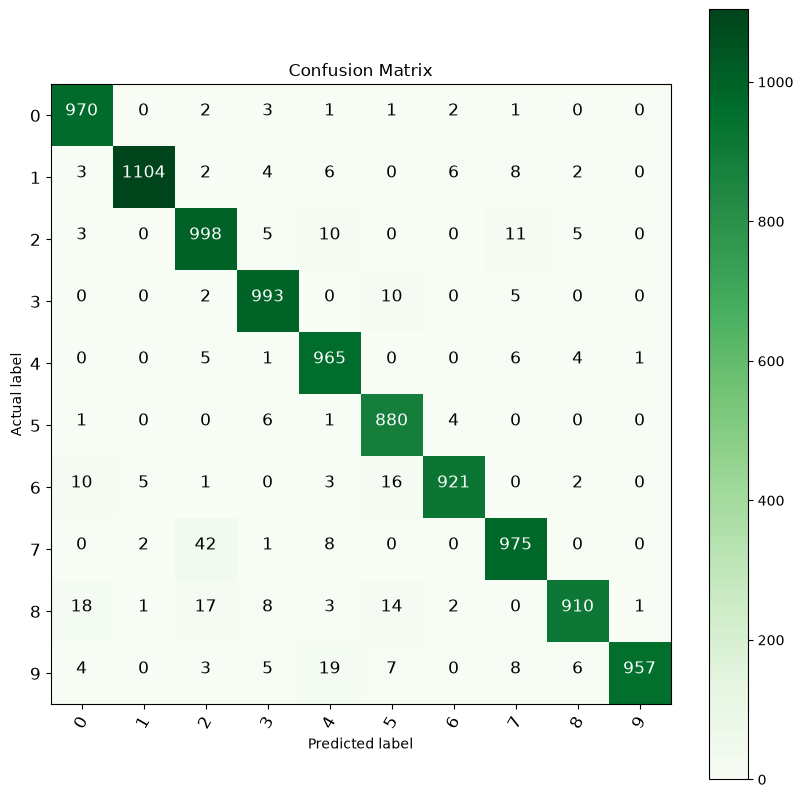

In [74]:
conf_matrix(y_test=labels_test, y_pred=model4.predict(x_test_1).argmax(axis=1), class_names=list(set(labels_test)))

Ins Auge stechen die vielen 7, die als 2 klassifiziert wurden - vielleicht ein Effekt der Rotation: eine um ein paar Grad gedrehte Sieben könnte als Zwei durchgehen. Interessanterweise gibt es weniger Fehler in der Gegenrichtung.

## Feature Maps visualisieren
Was passiert denn eigentlich in den Convolutional Layers, die die Feature Maps produzieren?

Mit einem Trick können wir visualisieren, was in jedem Layer passiert. Dazu erstellen wir ein neues Model mit den bereits trainierten Layers, aber markieren _jedes_ Layer als Output-Layer (statt nur des letzten).

Danach lassen wir ein zufälliges Bild im Feed-Forward-Mode durch das Model analysieren und zeigen den Zustand jedes Layers an.

In [49]:
# All taken from https://www.analyticsvidhya.com/blog/2020/11/tutorial-how-to-visualize-feature-maps-directly-from-cnn-layers/
# and https://machinelearningmastery.com/how-to-visualize-filters-and-feature-maps-in-convolutional-neural-networks/

# Create a model outputting all intermediate layers of our CNN:
layer_names = [layer.name for layer in model4.layers]
layer_outputs = [layer.output for layer in model4.layers]

viz_model = keras.models.Model(inputs=model4.inputs, outputs=layer_outputs)
viz_model.summary()

# Pick a random image, add a dimension to make it a one-length array of a single image.
exemplar = x_test_1[0]
exemplar = np.expand_dims(exemplar, axis=0)

# ... and feed it through the model
feature_maps = viz_model.predict(exemplar)

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_3            │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


### Convolutional Layer Output

Die verschiedenen Feature Outputs zeigen, dass die verschiedenen Features unterschiedliche Muster markieren, z.B. Kanten, oder nur Hell-Dunkel-Übergänge, vertikale oder horizontale Linien...

(1, 28, 28, 1)
(1, 28, 28, 1)
(1, 28, 28, 1)
(1, 26, 26, 32)
(1, 13, 13, 32)
(1, 11, 11, 64)
(1, 5, 5, 64)
(1, 1600)
(1, 1600)
(1, 10)


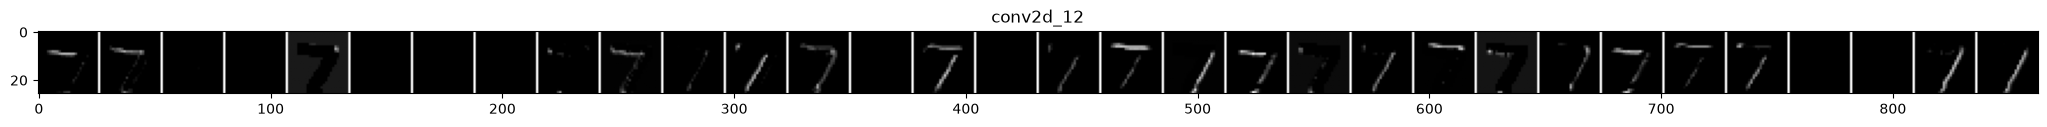

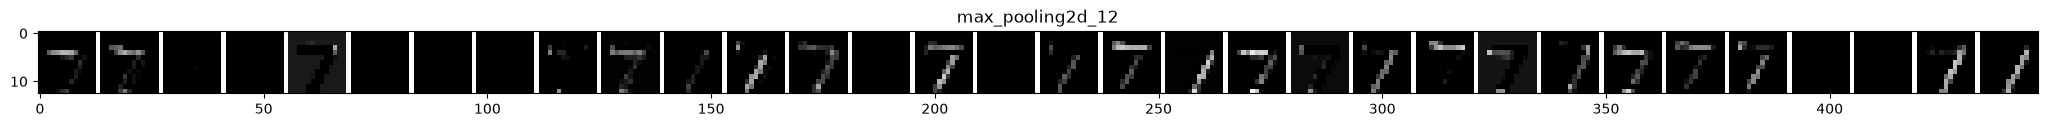

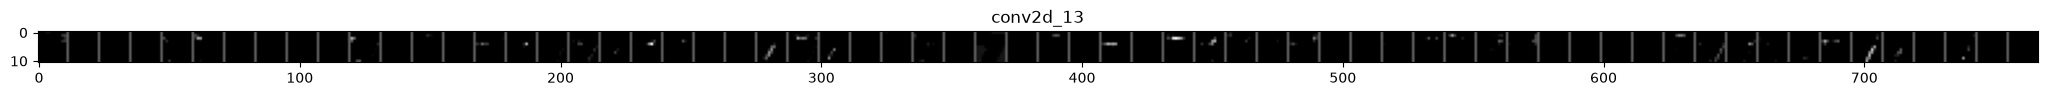

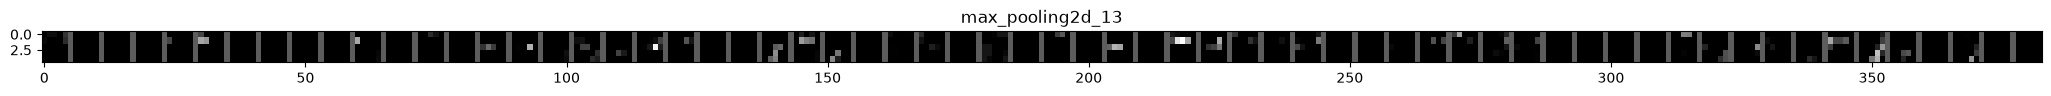

In [50]:
# Create images for layers
feature_map = feature_maps[0]

for layer_name, feature_map in zip(layer_names, feature_maps):
	shape = feature_map.shape
	print(shape)
	if (len(shape) != 4 or shape[3] == 1): 
		# skip non-conv layers
		continue

	# shape is something like (1, 28, 28, 32)
	feature_count = shape[-1]
	size = shape[1]
	border = 1
	placement = size + border
	grid = np.ones((size, feature_count * placement - border))
	for feature in range(feature_count):
		image = feature_map[0, :, :, feature]
		grid[:, feature * placement: (feature + 1) * placement - border] = image
	
	scale = 20 / feature_count
	figure = pyplot.figure(figsize=(scale * feature_count, scale))
	figure.add_axes((1, 1, 1, 1))
	pyplot.title(layer_name)
	pyplot.grid(False)
	pyplot.tick_params()
	pyplot.imshow(grid, aspect="auto", cmap="gray")


### Layer Weights

Wir können auch die Gewichte der Layers analysieren und erhalten ähnliche Muster für die Kernels wie oben gezeigt.

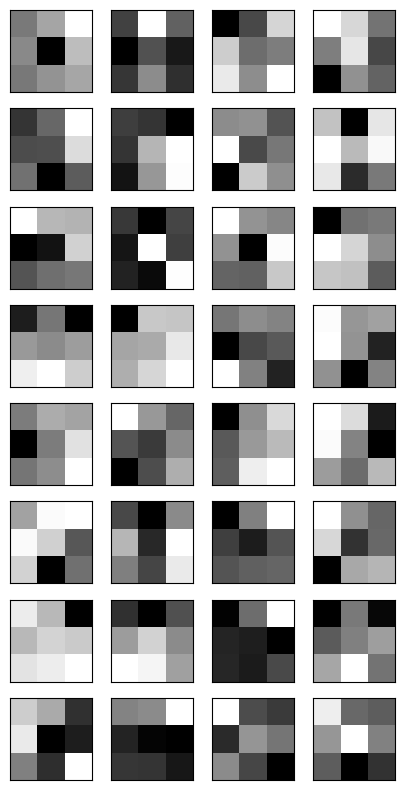

In [51]:
# retrieve weights from the second hidden layer
filters , bias = model4.layers[5].get_weights()
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = 32
ix=1
fig = pyplot.figure(figsize=(5,10))
for i in range(n_filters):
    # get the weights for each kernel
    # the third dimension are the color spaces, we have only 1 gray scale
    f = filters[:,:,0,i]
    # subplot for 6 filters and 3 channels
    cols = 4
    ax = pyplot.subplot(n_filters // cols,cols,ix)
    pyplot.imshow(f[:,:] ,cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ix+=1
#plot the filters 
pyplot.show()